# 1. Setup do Ambiente

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

# 2. Carregamento dos Dados

In [25]:
date_fns = pd.read_csv("../logs/method-reconstruction-experiment/date-fns/structured/result.csv")
directus  = pd.read_csv("../logs/method-reconstruction-experiment/directus/structured/result.csv")

df = pd.concat([date_fns, directus], ignore_index=True)

# 3. Limpeza e Tratamento de Dados

In [26]:
for col in ["isTestSuiteSuccessful", "isModelResultCompilable"]:
    df[col] = df[col].map({"true": True, "false": False, True: True, False: False})

df["passRate"] = df["testSuitePassedTestCaseCount"] / df["testSuiteTotalTestCaseCount"]
df["testCasePassRate"] = df["testSuitePassedTestCaseCount"] / df["testSuiteTotalTestCaseCount"]

df["contextType"] = df["experimentTitle"]
df["model"]       = df["modelName"]
df["permIdx"]     = df["experimentIndex"]
df["totalPerms"]  = df["experimentSize"]

df["subsetSize"]    = df["relevantTestCaseCount"]
df["isFullContext"] = df["contextType"] == "all-relevant-test-case"

print(df.shape)
df.head(3)

(184, 32)


,repositoryName,methodName,methodResolvedFilePath,experimentTitle,experimentDescription,experimentContextItemCount,experimentIndex,experimentSize,experimentContextSlugs,modelSystemPrompt,...,sourceFileWithOriginalMethodBody,sourceFileWithReconstructedMethodBody,passRate,testCasePassRate,contextType,model,permIdx,totalPerms,subsetSize,isFullContext
0,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,all-relevant-test-case,areIntervalsOverlapping > all-relevant-test-ca...,5,1,1,relevant-test-case,"""# SYSTEM PROMPT: METHOD RECONSTRUCTOR\n\n## 1...",...,"""import { toDate } from \""../toDate/index.ts\""...","""import { toDate } from \""../toDate/index.ts\""...",1.0,1.0,all-relevant-test-case,gemini-2.5-flash,1,1,5,True
1,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,permuted-relevant-test-case,areIntervalsOverlapping > permuted-relevant-te...,5,1,5,relevant-test-case,"""# SYSTEM PROMPT: METHOD RECONSTRUCTOR\n\n## 1...",...,"""import { toDate } from \""../toDate/index.ts\""...","""import { toDate } from \""../toDate/index.ts\""...",1.0,1.0,permuted-relevant-test-case,gemini-2.5-flash,1,5,5,False
2,date-fns,areIntervalsOverlapping,/home/guilhermebkel/Personal/tcc-context-impor...,permuted-relevant-test-case,areIntervalsOverlapping > permuted-relevant-te...,4,2,5,relevant-test-case,"""# SYSTEM PROMPT: METHOD RECONSTRUCTOR\n\n## 1...",...,"""import { toDate } from \""../toDate/index.ts\""...","""import { toDate } from \""../toDate/index.ts\""...",1.0,1.0,permuted-relevant-test-case,gemini-2.5-flash,2,5,4,False


In [27]:
print("Repositórios:", df["repositoryName"].value_counts().to_dict())
print("Métodos únicos:", df["methodName"].nunique())
print("Modelos:", df["model"].unique())
print("Tipos de contexto:", df["contextType"].unique())

print("\n")
print("Linhas por (modelo, contextType):")
print(df.groupby(["model", "contextType"]).size().to_string())
print("\n")

print("Taxa global de sucesso [test-suite]:", round(df["isTestSuiteSuccessful"].mean(), 4))
print("Taxa global de sucesso [test-case]:", round(df["testCasePassRate"].mean(), 4))
print("Taxa global de compilabilidade:", round(df["isModelResultCompilable"].mean(), 4))

Repositórios: {'directus': 108, 'date-fns': 76}
Métodos únicos: 10
Modelos: ['gemini-2.5-flash' 'gemini-3.0-flash']
Tipos de contexto: ['all-relevant-test-case' 'permuted-relevant-test-case'
 'no-relevant-test-case']


Linhas por (modelo, contextType):
model             contextType                
gemini-2.5-flash  all-relevant-test-case         10
                  no-relevant-test-case          10
                  permuted-relevant-test-case    72
gemini-3.0-flash  all-relevant-test-case         10
                  no-relevant-test-case          10
                  permuted-relevant-test-case    72


Taxa global de sucesso [test-suite]: 0.1685
Taxa global de sucesso [test-case]: 0.6868
Taxa global de compilabilidade: 0.6739


# 4. Análise Exploratória de Dados

## Análise em Código

In [28]:
CONTEXT_ORDER = ["no-relevant-test-case", "all-relevant-test-case", "permuted-relevant-test-case"]
CONTEXT_LABELS = {
    "no-relevant-test-case":       "Sem testes",
    "all-relevant-test-case":      "Todos os testes relevantes",
    "permuted-relevant-test-case": "Testes permutados",
}

METRICS = [
    ("isTestSuiteSuccessful", "Suíte completamente aprovada (%)"),
    ("testCasePassRate",       "Test cases aprovados (%)"),
]

### Taxa de aprovação por tipo de contexto e modelo

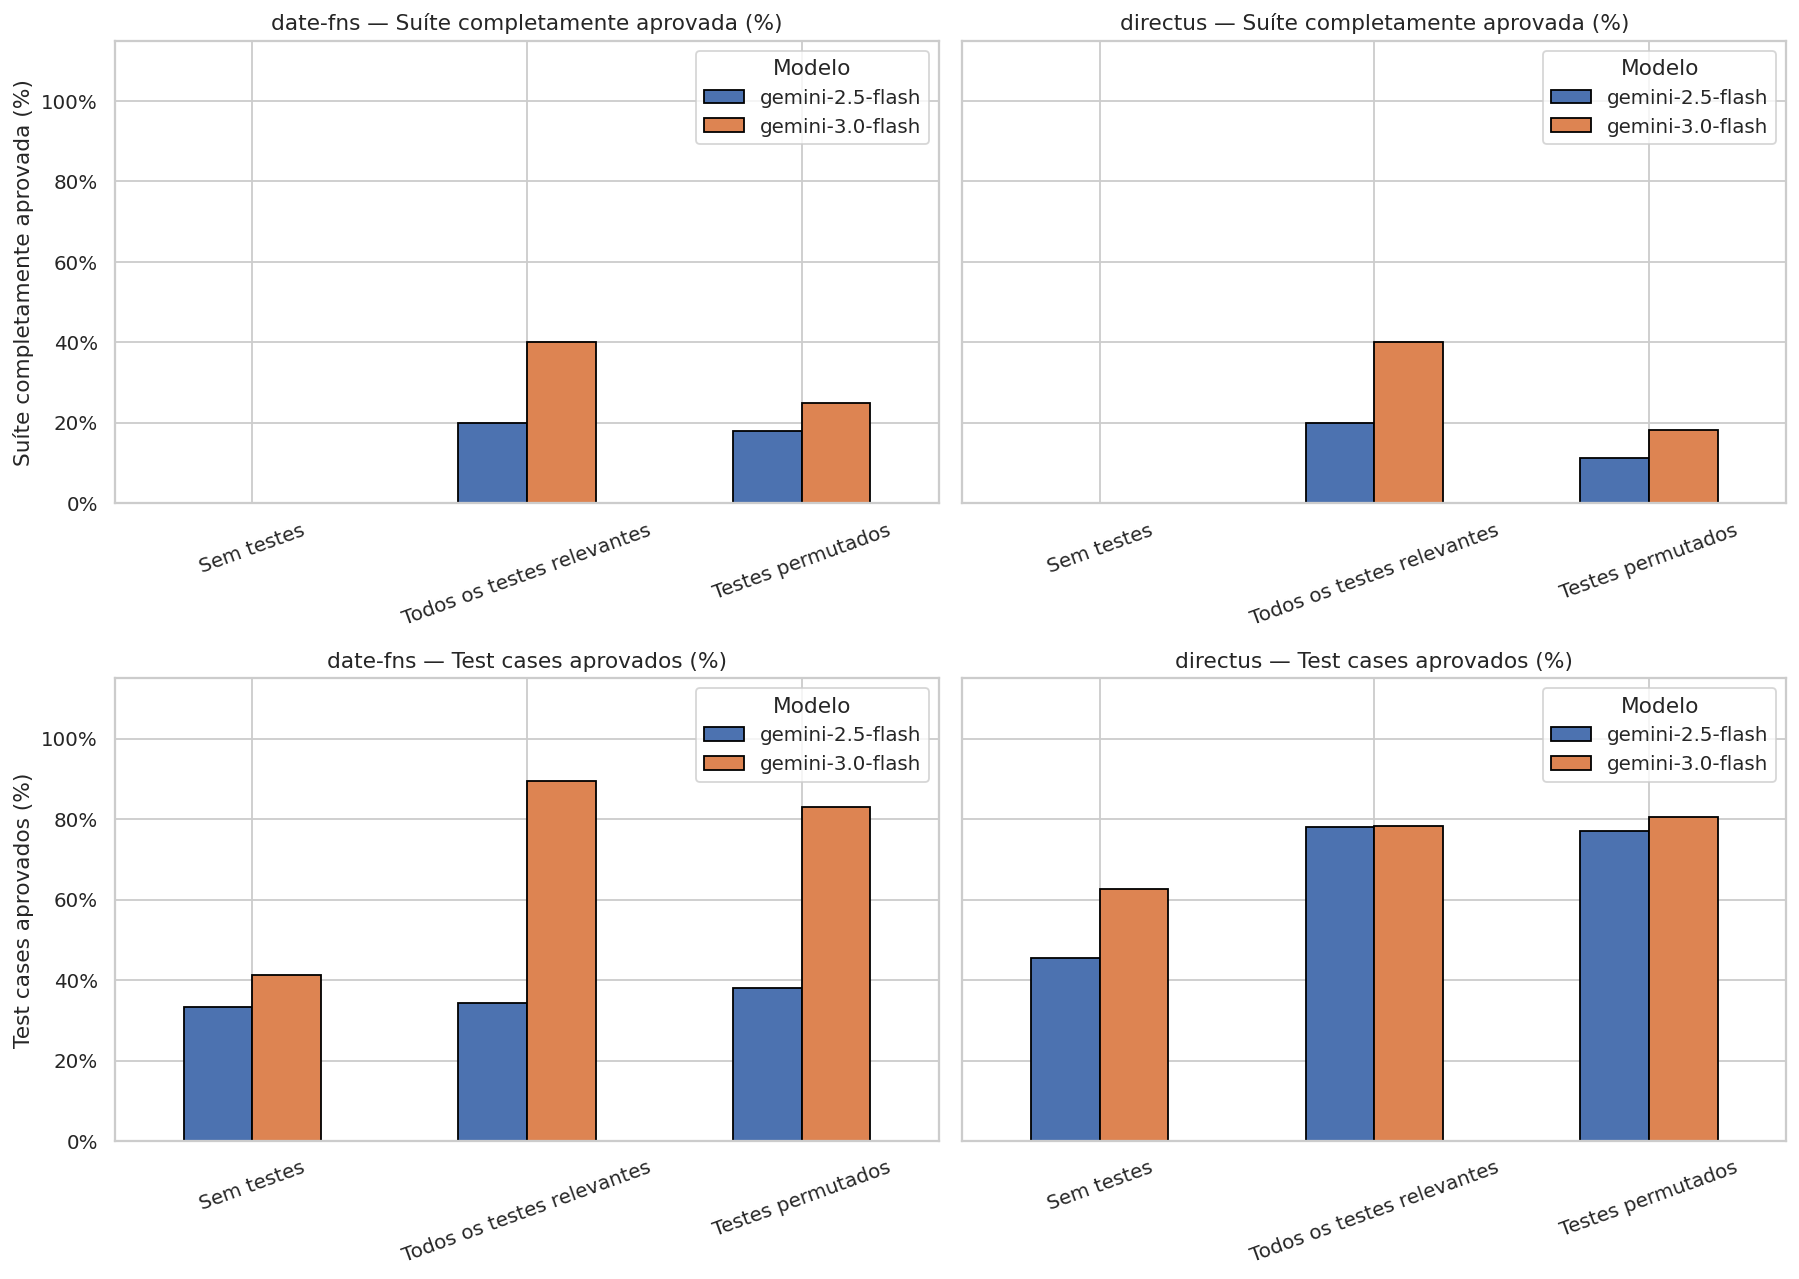

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for row, (metric_col, metric_label) in enumerate(METRICS):
    for col, repo in enumerate(df["repositoryName"].dropna().unique()):
        ax = axes[row][col]
        subset = df[df["repositoryName"] == repo]
        rates = (
            subset.groupby(["contextType", "model"])[metric_col]
            .mean()
            .unstack("model")
            .reindex([c for c in CONTEXT_ORDER if c in subset["contextType"].unique()])
        )
        rates.index = [CONTEXT_LABELS.get(i, i) for i in rates.index]
        rates = rates * 100
        rates.plot(kind="bar", ax=ax, edgecolor="black")
        ax.set_title(f"{repo} — {metric_label}")
        ax.set_ylabel(metric_label)
        ax.set_ylim(0, 115)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.tick_params(axis="x", rotation=20)
        ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("success_by_context_model.png", bbox_inches="tight")
plt.show()

### Suíte completamente aprovada por método, contexto e modelo

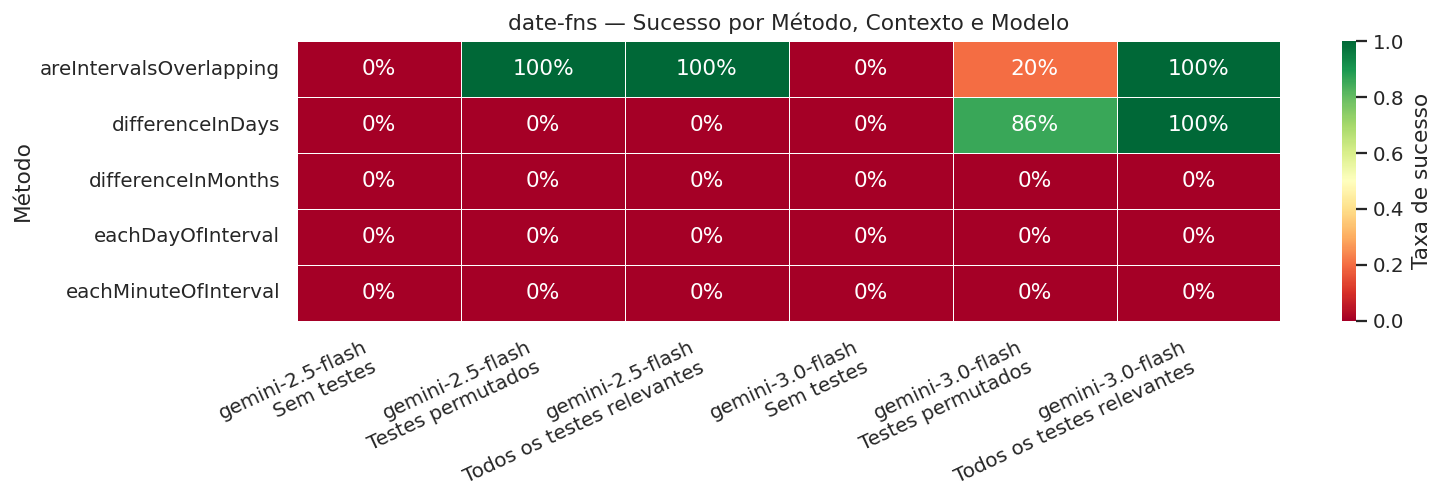

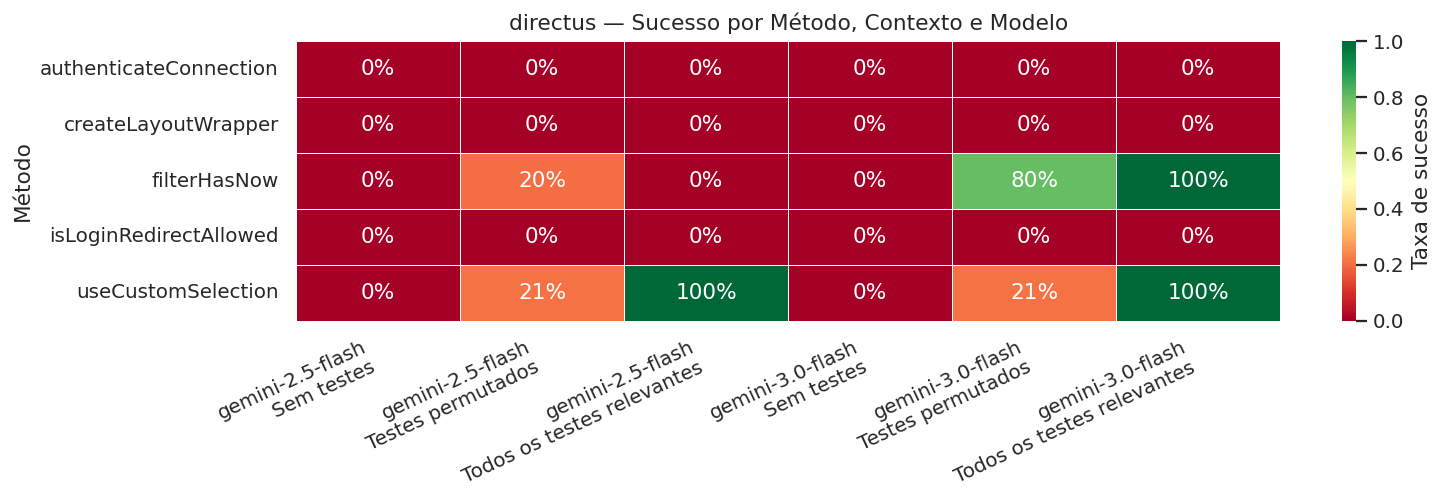

In [30]:
for repo in df["repositoryName"].dropna().unique():
    pivot = (
        df[df["repositoryName"] == repo]
        .groupby(["methodName", "contextType", "model"])["isTestSuiteSuccessful"]
        .mean()
        .reset_index()
        .assign(col=lambda d: d["model"] + "\n" + d["contextType"].map(CONTEXT_LABELS).fillna(d["contextType"]))
        .pivot(index="methodName", columns="col", values="isTestSuiteSuccessful")
        .fillna(np.nan)
    )
    plt.figure(figsize=(max(8, len(pivot.columns) * 2), max(4, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": "Taxa de sucesso"})
    plt.title(f"{repo} — Sucesso por Método, Contexto e Modelo")
    plt.xlabel("")
    plt.ylabel("Método")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(f"heatmap_method_{repo}.png", bbox_inches="tight")
    plt.show()

### Compilabilidade por tipo de contexto e modelo

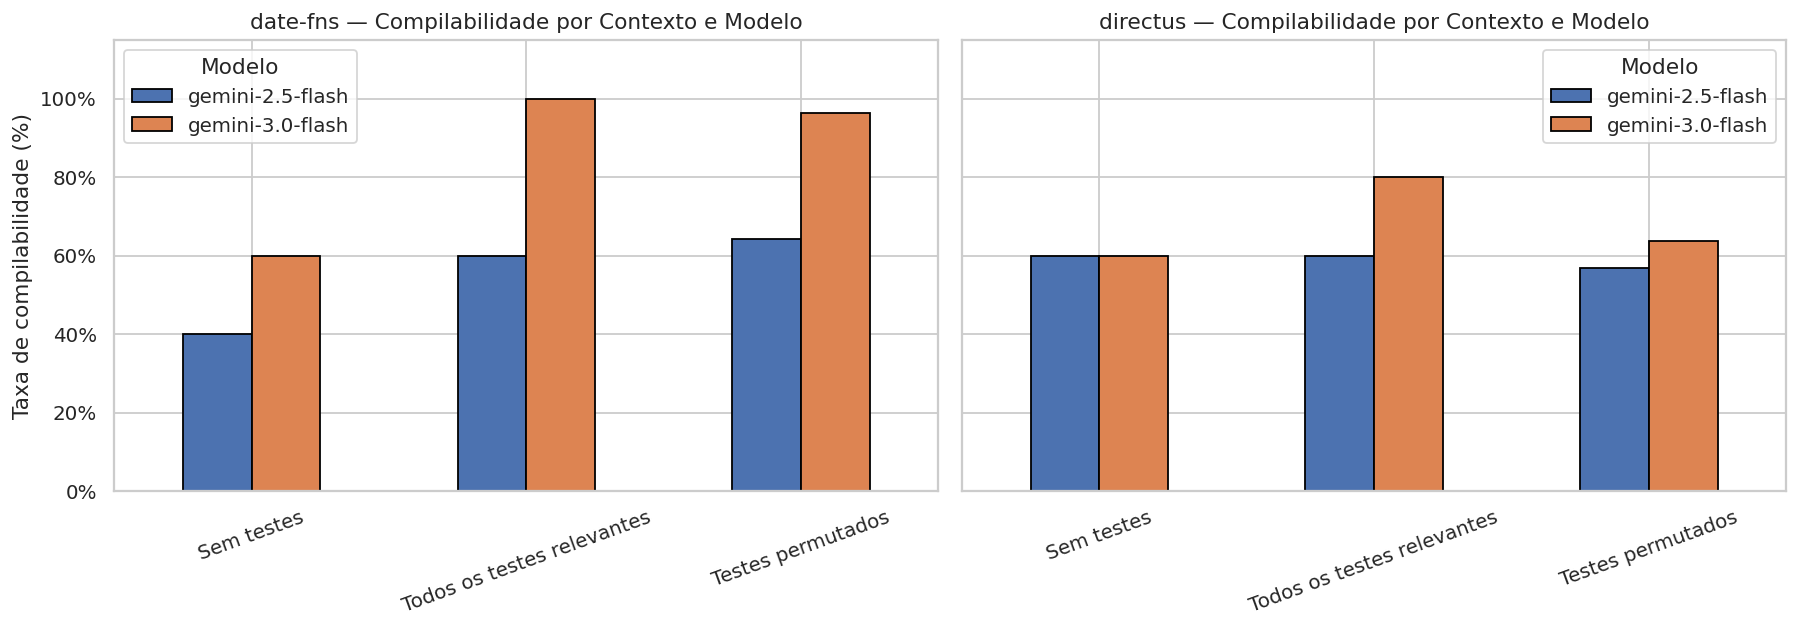

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, df["repositoryName"].dropna().unique()):
    subset = df[df["repositoryName"] == repo]
    rates = (
        subset.groupby(["contextType", "model"])["isModelResultCompilable"]
        .mean()
        .unstack("model")
        .reindex([c for c in CONTEXT_ORDER if c in subset["contextType"].unique()])
    )
    rates.index = [CONTEXT_LABELS.get(i, i) for i in rates.index]
    rates = rates * 100
    rates.plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title(f"{repo} — Compilabilidade por Contexto e Modelo")
    ax.set_ylabel("Taxa de compilabilidade (%)")
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("compilable_by_context_model.png", bbox_inches="tight")
plt.show()

### Impacto do número de testes relevantes no pass rate

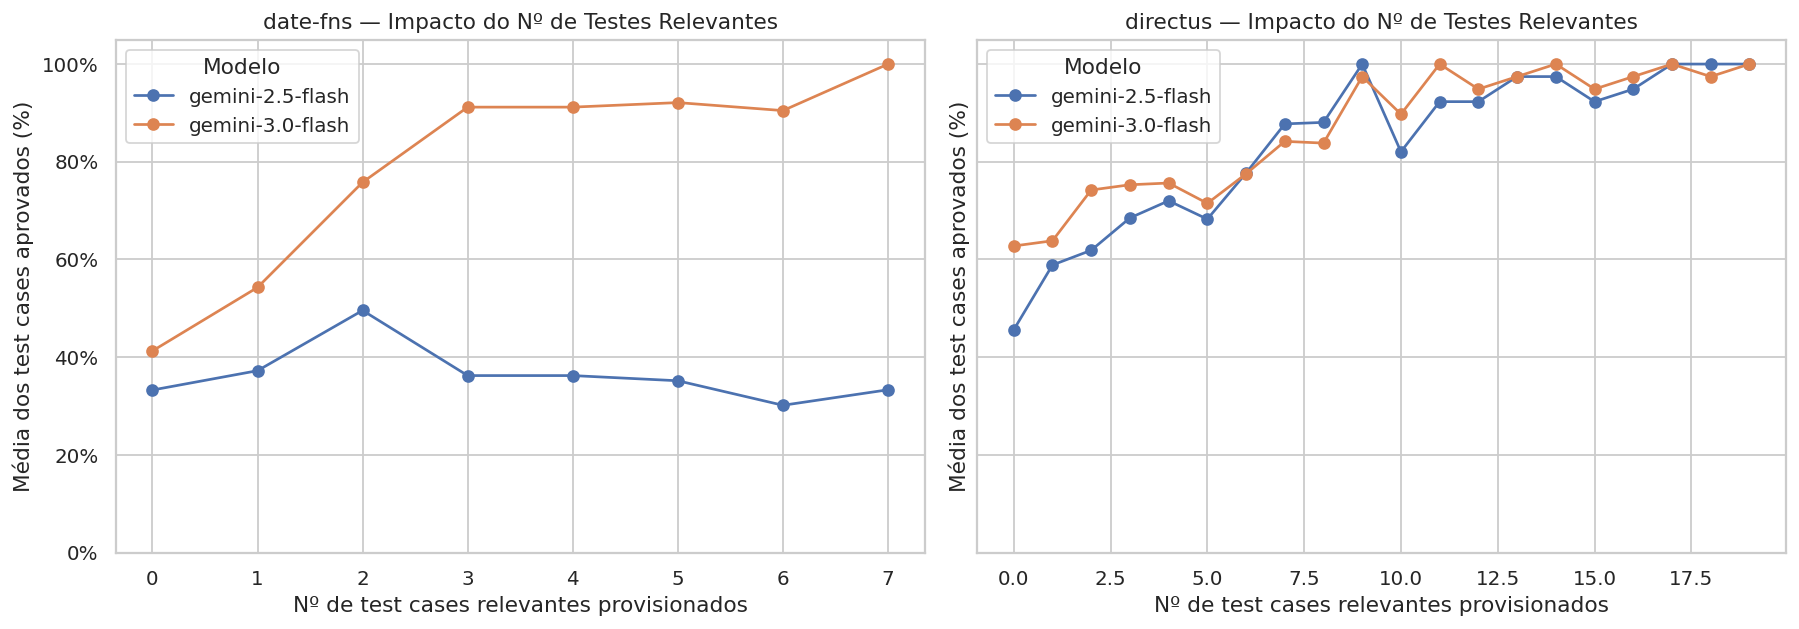

In [32]:
impact = (
    df.assign(testCasePassRateClamped=df["testCasePassRate"].clip(0, 1))
    .groupby(["repositoryName", "relevantTestCaseCount", "model"])["testCasePassRateClamped"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, repo in zip(axes, df["repositoryName"].dropna().unique()):
    d = impact[impact["repositoryName"] == repo]
    for model_name, group in d.groupby("model"):
        group = group.sort_values("relevantTestCaseCount")
        ax.plot(group["relevantTestCaseCount"], group["testCasePassRateClamped"] * 100,
                marker="o", label=model_name)
    ax.set_title(f"{repo} — Impacto do Nº de Testes Relevantes")
    ax.set_xlabel("Nº de test cases relevantes provisionados")
    ax.set_ylabel("Média dos test cases aprovados (%)")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Modelo")

plt.tight_layout()
plt.savefig("impact_relevant_test_count.png", bbox_inches="tight")
plt.show()

## Análise em Linguagem Natural

### Setup do Agente

In [33]:
import os
from dotenv import load_dotenv
from google import genai
from pandasai import Agent
from pandasai.llm.base import LLM

load_dotenv("../.env")

class GoogleGenAILLM(LLM):
    def __init__(self, model: str, api_key: str):
        self.model = model
        self._client = genai.Client(api_key=api_key)

    def call(self, instruction, context=None):
        self.last_prompt = instruction.to_string()
        response = self._client.models.generate_content(
            model=self.model,
            contents=self.last_prompt,
        )
        return response.text

    @property
    def type(self) -> str:
        return "google-genai"

llm = GoogleGenAILLM(model="gemini-3-flash-preview", api_key=os.environ["GOOGLE_GENERATIVE_AI_API_KEY"])
agent = Agent([df], config={"llm": llm, "verbose": False, "custom_whitelisted_dependencies": ["os"], "open_charts": False})

In [34]:
from IPython.display import display, Markdown, Image
import os

def show_agent_result(result):
    if isinstance(result, str) and os.path.isfile(result):
        display(Image(filename=result))
    elif isinstance(result, str):
        display(Markdown(result))
    else:
        display(result)


### Perguntas para o Agente

---
### Quais métodos foram reconstruídos com sucesso em todos os contextos testados?

Os métodos reconstruídos com sucesso em todos os contextos testados foram: Nenhum método foi reconstruído com sucesso em todos os contextos testados.

---
### Quais métodos nunca foram reconstruídos com sucesso, independente do contexto ou modelo?

,methodName
0,authenticateConnection
1,createLayoutWrapper
2,differenceInMonths
3,eachDayOfInterval
4,eachMinuteOfInterval
5,isLoginRedirectAllowed


---
### Resuma os principais achados do experimento em tópicos.


### Principais Achados do Experimento:

*   **Importância do Contexto:** O tipo de contexto 'all-relevant-test-case' obteve a melhor performance (30.00% de sucesso), demonstrando que a relevância dos casos de teste fornecidos é crucial para a reconstrução precisa de métodos.
*   **Performance dos Modelos:** O modelo **gemini-3.0-flash** superou o outro com uma taxa de sucesso de **20.65%** na execução das suítes de testes.
*   **Alta Compilabilidade:** **67.39%** do código gerado pelos modelos foi compilável, indicando uma forte capacidade sintática, mesmo quando a lógica interna falhou nos testes funcionais.
*   **Volume de Contexto:** A correlação entre o número de casos de teste relevantes e a taxa de aprovação foi de **0.42**, sugerindo que fornecer mais exemplos pertinentes auxilia na precisão do modelo.
*   **Consistência entre Repositórios:** O experimento cobriu múltiplos repositórios (como date-fns, directus), mostrando que a eficácia da técnica de TDD com LLMs varia conforme a complexidade da base de código.


---
### Existe algum padrão claro que indique quando o contexto de testes ajuda e quando não ajuda?

<string>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



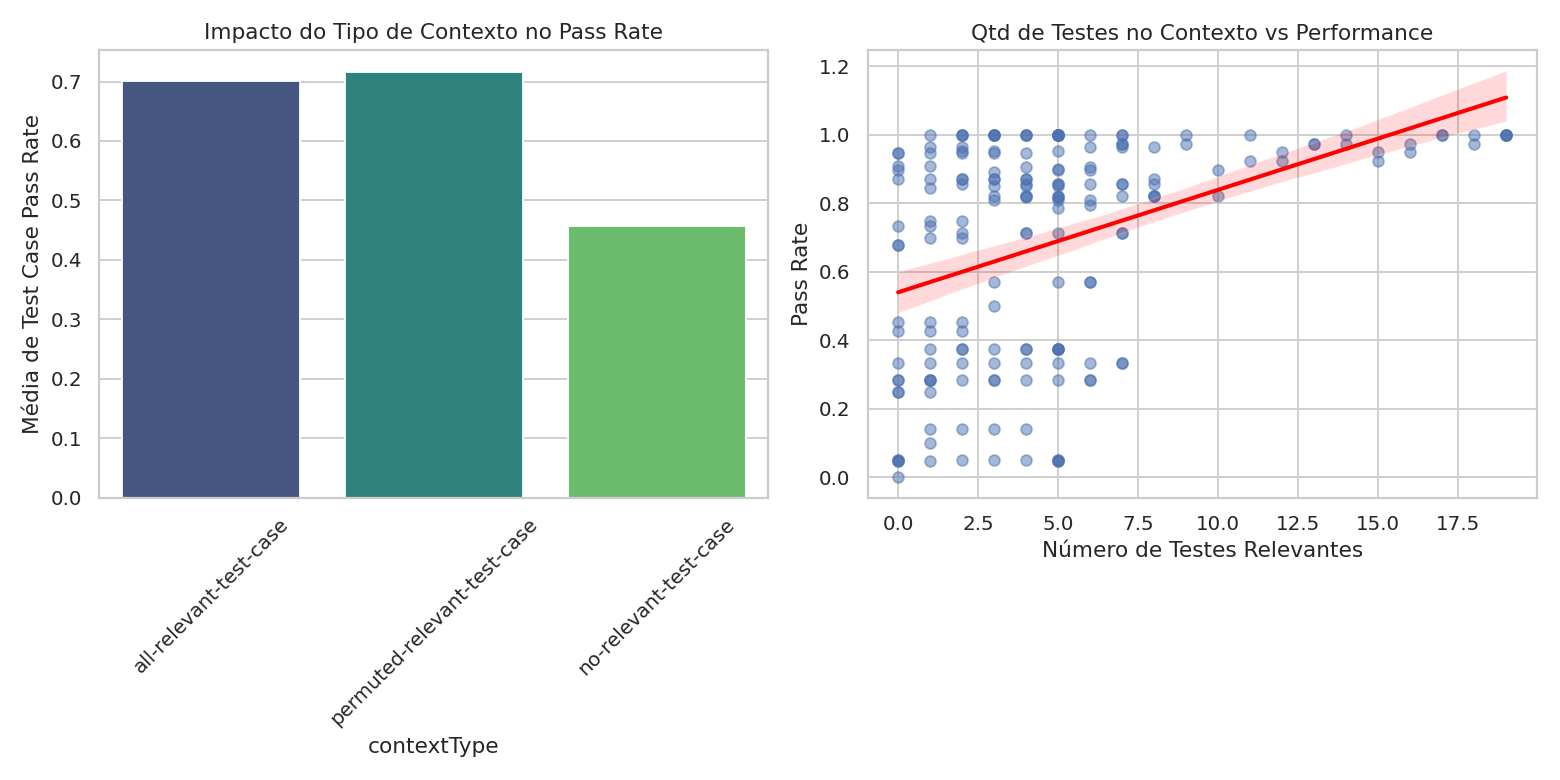

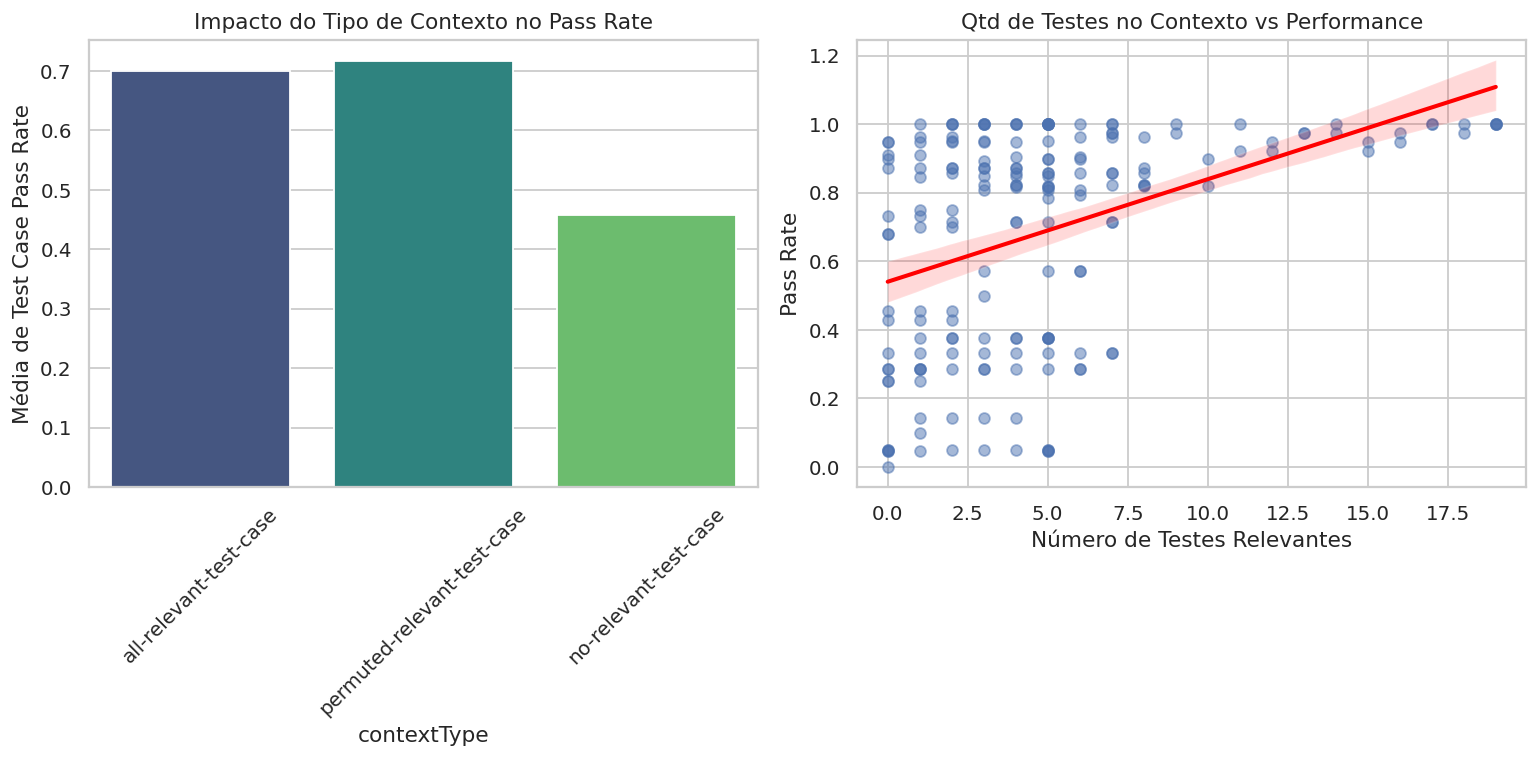

In [35]:
questions = [
    "Quais métodos foram reconstruídos com sucesso em todos os contextos testados?",
    "Quais métodos nunca foram reconstruídos com sucesso, independente do contexto ou modelo?",
    "Resuma os principais achados do experimento em tópicos.",
    "Existe algum padrão claro que indique quando o contexto de testes ajuda e quando não ajuda?"
]

for question in questions:
    display(Markdown(f"---\n### {question}"))
    show_agent_result(agent.chat(question))

# 5. Perguntas de Pesquisa

## RQ1 — Qual a relevância dos testes de unidade para geração de métodos?

### Gráfico 1.1 — Impacto binário do contexto (Q1)

Compara diretamente sem contexto vs. com todos os testes relevantes.

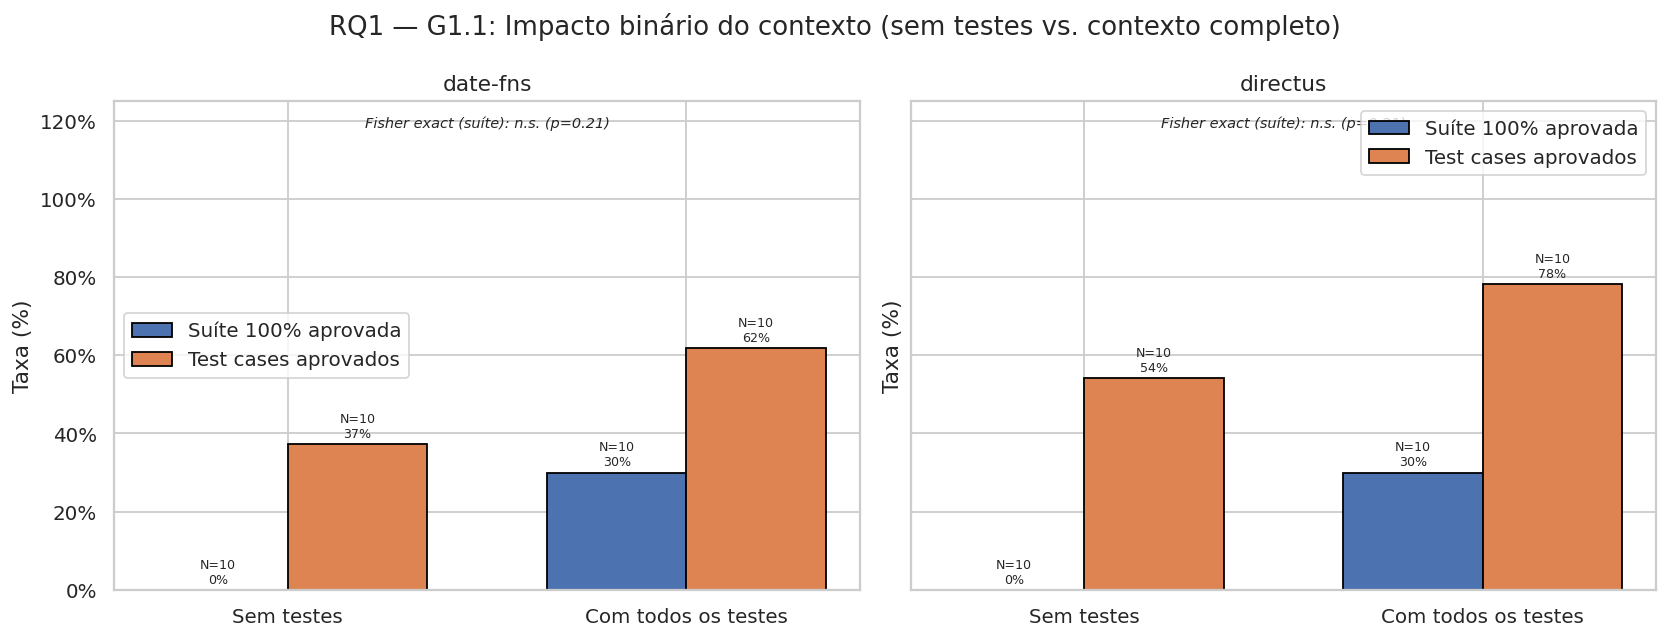

In [36]:
from scipy.stats import fisher_exact

rq1_contexts = ["no-relevant-test-case", "all-relevant-test-case"]
rq1_labels   = {"no-relevant-test-case": "Sem testes", "all-relevant-test-case": "Com todos os testes"}

subset = df[df["contextType"].isin(rq1_contexts)].copy()
subset["contextLabel"] = subset["contextType"].map(rq1_labels)

metrics = [("isTestSuiteSuccessful", "Suíte 100% aprovada"), ("testCasePassRate", "Test cases aprovados")]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, repo in zip(axes, df["repositoryName"].unique()):
    d = subset[subset["repositoryName"] == repo]
    labels = list(rq1_labels.values())
    x = np.arange(len(labels))
    width = 0.35

    for i, (col, name) in enumerate(metrics):
        means = [d[d["contextLabel"] == l][col].mean() * 100 for l in labels]
        ns    = [len(d[d["contextLabel"] == l]) for l in labels]
        bars  = ax.bar(x + i * width, means, width, label=name, edgecolor="black")
        for bar, n, val in zip(bars, ns, means):
            ax.annotate(f"N={n}\n{val:.0f}%",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1),
                        ha="center", va="bottom", fontsize=7)

    # Fisher's exact test (isTestSuiteSuccessful)
    no_s  = d[d["contextType"] == "no-relevant-test-case"]["isTestSuiteSuccessful"].astype(int)
    all_s = d[d["contextType"] == "all-relevant-test-case"]["isTestSuiteSuccessful"].astype(int)
    table = [[no_s.sum(), len(no_s) - no_s.sum()], [all_s.sum(), len(all_s) - all_s.sum()]]
    _, p  = fisher_exact(table)
    sig   = f"* p={p:.3f}" if p < 0.05 else f"n.s. (p={p:.2f})"
    ax.text(0.5, 0.97, f"Fisher exact (suíte): {sig}", ha="center", va="top",
            transform=ax.transAxes, fontsize=8, style="italic")

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(labels)
    ax.set_title(f"{repo}")
    ax.set_ylabel("Taxa (%)")
    ax.set_ylim(0, 125)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()

plt.suptitle("RQ1 — G1.1: Impacto binário do contexto (sem testes vs. contexto completo)")
plt.tight_layout()
plt.savefig("figures/rq1_context_vs_no_context.png", bbox_inches="tight")
plt.show()

### Gráfico 1.2 — Quantidade de testes × taxa de sucesso (Q2)

Usa os experimentos permutados onde o subconjunto varia de 1 a N.

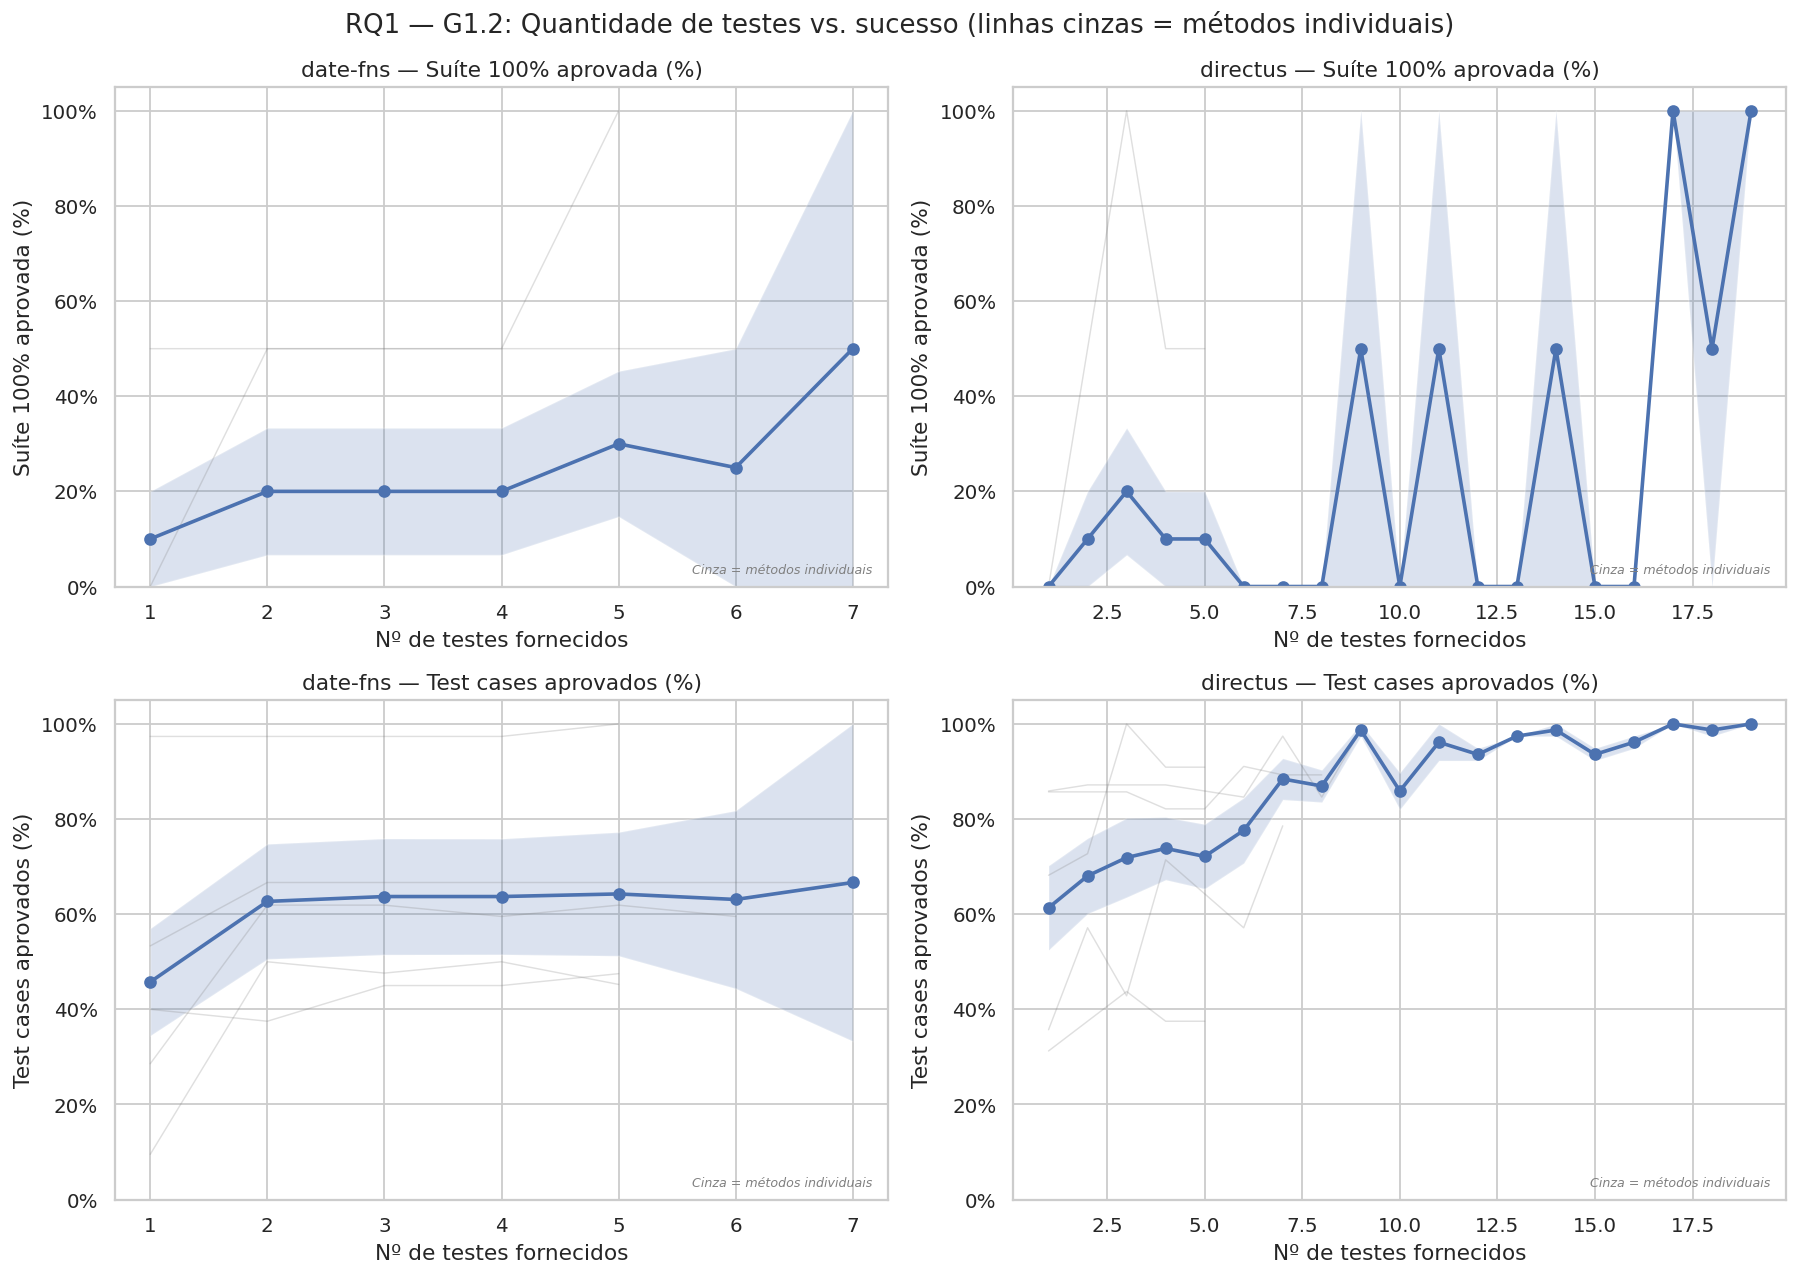

In [37]:
permuted = df[df["contextType"] == "permuted-relevant-test-case"].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, (metric_col, metric_label) in enumerate([
    ("isTestSuiteSuccessful", "Suíte 100% aprovada (%)"),
    ("testCasePassRate",      "Test cases aprovados (%)"),
]):
    impact = (
        permuted.groupby(["repositoryName", "experimentContextItemCount"])[metric_col]
        .agg(["mean", "sem"])
        .reset_index()
    )

    for row_idx, repo in enumerate(df["repositoryName"].unique()):
        ax = axes[col_idx][row_idx]

        # Linhas por método (fundo, semi-transparentes)
        for method, grp in permuted[permuted["repositoryName"] == repo].groupby("methodName"):
            m = (grp.groupby("experimentContextItemCount")[metric_col]
                 .mean().reset_index().sort_values("experimentContextItemCount"))
            ax.plot(m["experimentContextItemCount"], m[metric_col] * 100,
                    alpha=0.25, linewidth=0.8, color="gray")

        # Linha agregada com banda de erro padrão
        d = impact[impact["repositoryName"] == repo].sort_values("experimentContextItemCount")
        ax.plot(d["experimentContextItemCount"], d["mean"] * 100, marker="o", linewidth=2, label="Média")
        ax.fill_between(d["experimentContextItemCount"],
                        (d["mean"] - d["sem"]) * 100, (d["mean"] + d["sem"]) * 100, alpha=0.2)

        ax.set_title(f"{repo} — {metric_label}")
        ax.set_xlabel("Nº de testes fornecidos")
        ax.set_ylabel(metric_label)
        ax.set_ylim(0, 105)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.text(0.98, 0.02, "Cinza = métodos individuais", ha="right", va="bottom",
                transform=ax.transAxes, fontsize=7, color="gray", style="italic")

plt.suptitle("RQ1 — G1.2: Quantidade de testes vs. sucesso (linhas cinzas = métodos individuais)")
plt.tight_layout()
plt.savefig("figures/rq1_test_count_vs_success.png", bbox_inches="tight")
plt.show()

### Gráfico 1.3 — Ponto de estabilização (Q3)

Boxplot por tamanho de subconjunto — mostra quando a variância cai e a mediana estabiliza.

/tmp/ipykernel_196722/1033977456.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_size, labels=sizes, patch_artist=True,
/tmp/ipykernel_196722/1033977456.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_per_size, labels=sizes, patch_artist=True,


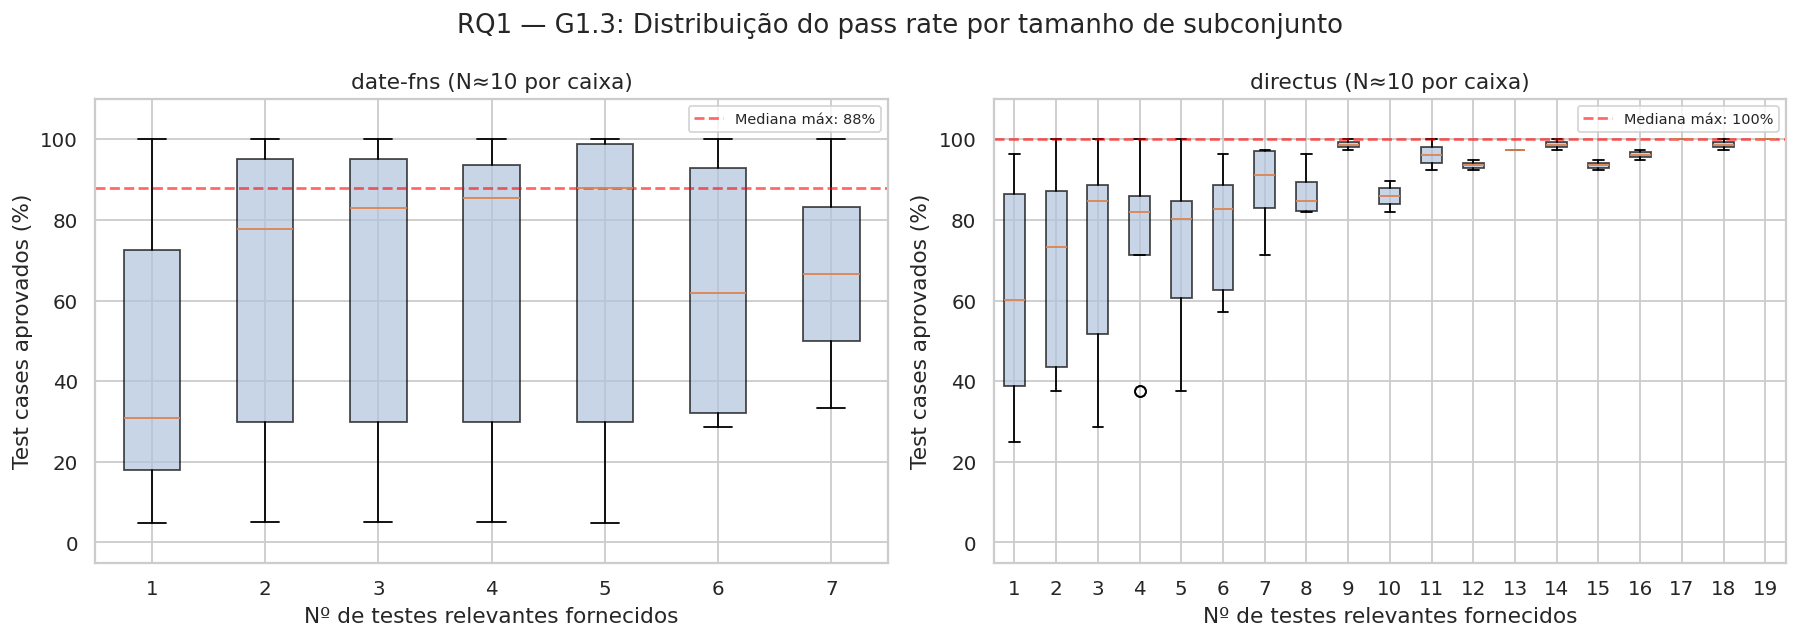

In [38]:
permuted = df[df["contextType"] == "permuted-relevant-test-case"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, repo in zip(axes, permuted["repositoryName"].unique()):
    d = permuted[permuted["repositoryName"] == repo]
    sizes = sorted(d["experimentContextItemCount"].unique())
    data_per_size = [
        d[d["experimentContextItemCount"] == s]["testCasePassRate"].dropna() * 100
        for s in sizes
    ]
    n_per_box = len(data_per_size[0]) if data_per_size else "?"

    ax.boxplot(data_per_size, labels=sizes, patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue", alpha=0.7))

    # Linha de referência na mediana máxima
    valid = [dp for dp in data_per_size if len(dp) > 0]
    max_med = max(np.median(dp) for dp in valid)
    ax.axhline(max_med, linestyle="--", color="red", alpha=0.6,
               label=f"Mediana máx: {max_med:.0f}%")

    ax.set_title(f"{repo} (N≈{int(n_per_box)} por caixa)")
    ax.set_xlabel("Nº de testes relevantes fornecidos")
    ax.set_ylabel("Test cases aprovados (%)")
    ax.set_ylim(-5, 110)
    ax.legend(fontsize=8)

plt.suptitle("RQ1 — G1.3: Distribuição do pass rate por tamanho de subconjunto")
plt.tight_layout()
plt.savefig("figures/rq1_stabilization.png", bbox_inches="tight")
plt.show()

### Gráfico 1.4 — Heatmap por método × quantidade de testes

Mostra quais métodos precisam de mais testes para convergir — informação que a curva agregada esconde.

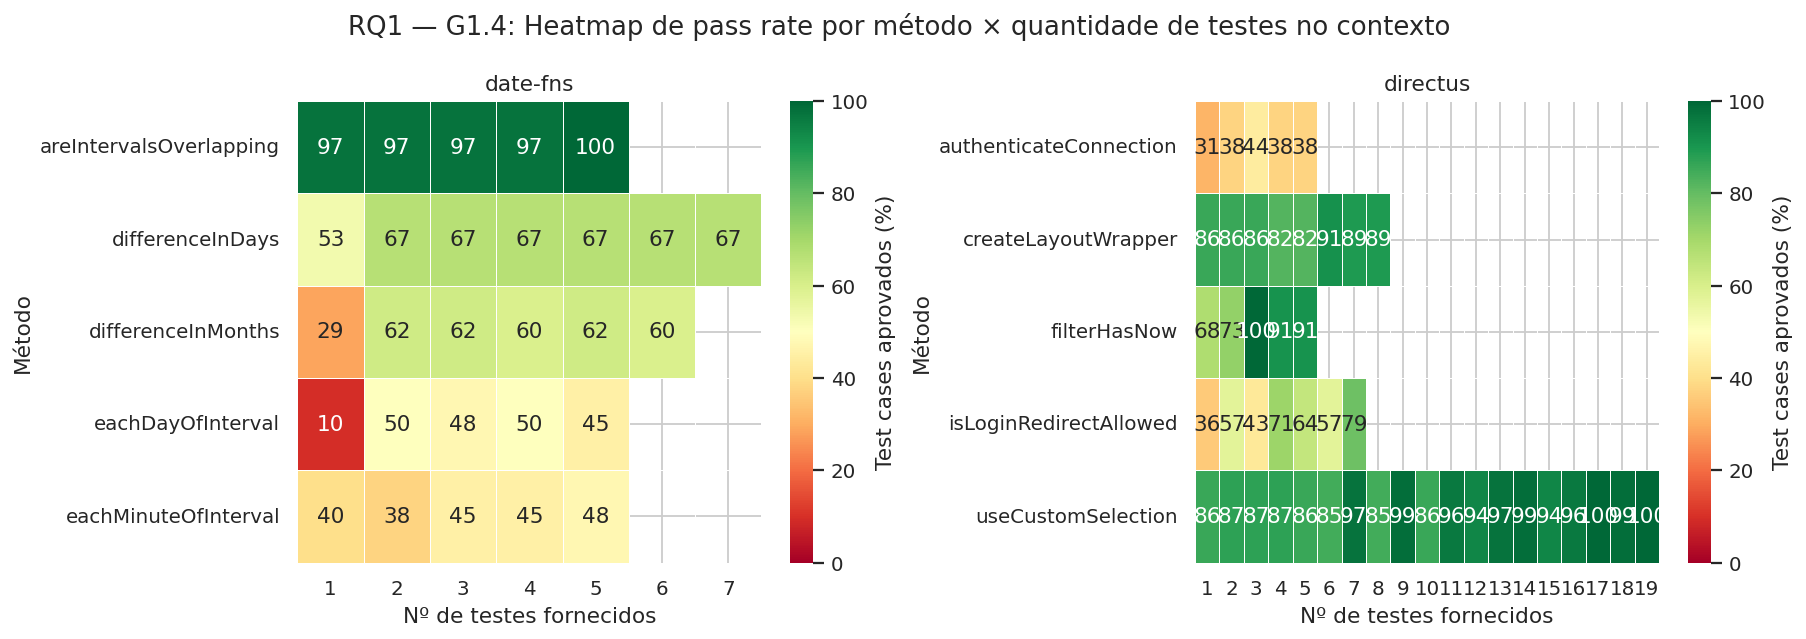

In [39]:
permuted = df[df["contextType"] == "permuted-relevant-test-case"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, repo in zip(axes, permuted["repositoryName"].unique()):
    d = permuted[permuted["repositoryName"] == repo]
    pivot = (
        d.groupby(["methodName", "experimentContextItemCount"])["testCasePassRate"]
        .mean()
        .unstack("experimentContextItemCount")
        .sort_index()
    )
    sns.heatmap(pivot * 100, ax=ax, cmap="RdYlGn", vmin=0, vmax=100,
                annot=True, fmt=".0f", linewidths=0.3,
                cbar_kws={"label": "Test cases aprovados (%)"})
    ax.set_title(f"{repo}")
    ax.set_xlabel("Nº de testes fornecidos")
    ax.set_ylabel("Método")

plt.suptitle("RQ1 — G1.4: Heatmap de pass rate por método × quantidade de testes no contexto")
plt.tight_layout()
plt.savefig("figures/rq1_method_heatmap.png", bbox_inches="tight")
plt.show()

## RQ2 — Quais tipos de testes contribuem mais?

### Gráfico 2.1 — Suficiência dos testes MT completos (Q5)

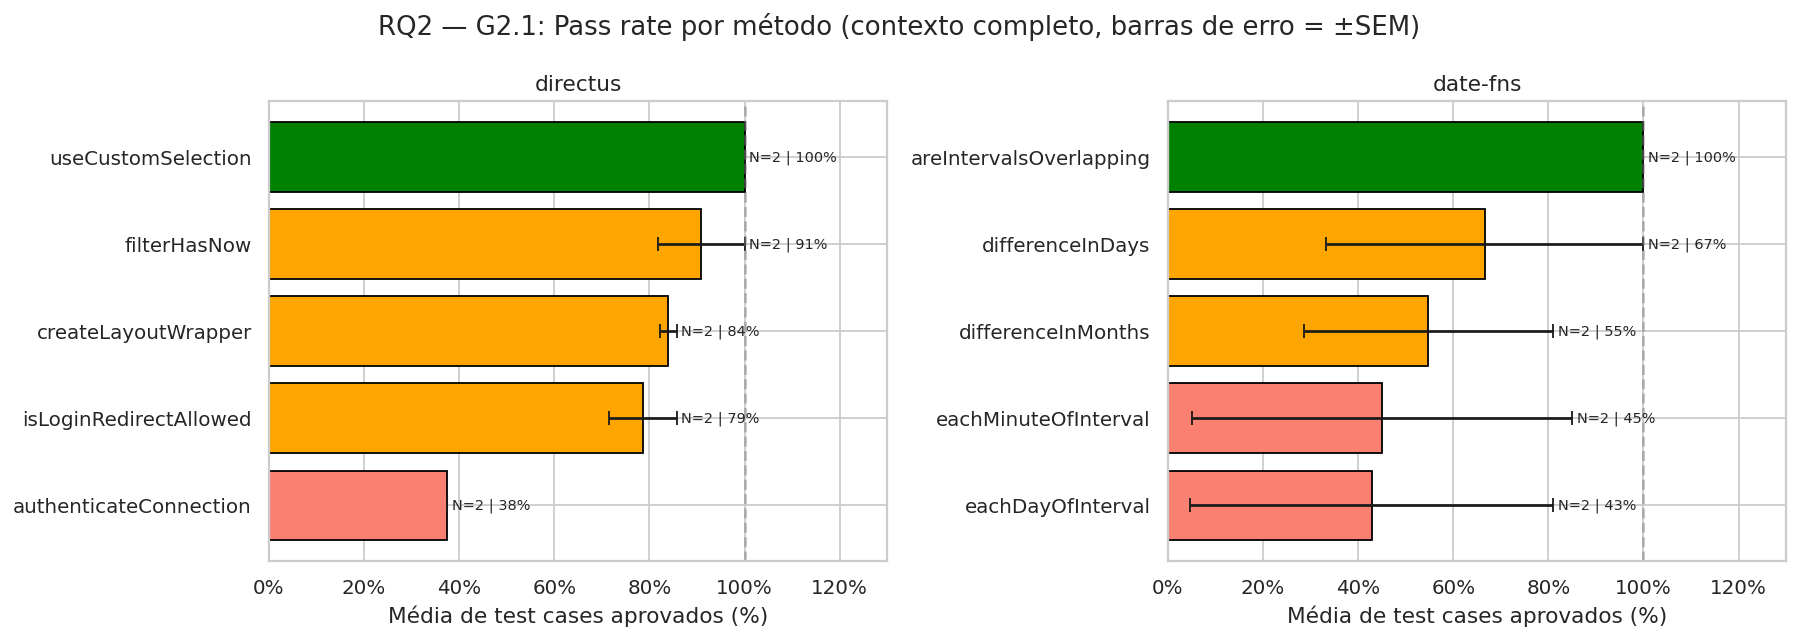

In [40]:
full_ctx = df[df["contextType"] == "all-relevant-test-case"].copy()

rates = (
    full_ctx.groupby(["repositoryName", "methodName"])["testCasePassRate"]
    .agg(["mean", "sem", "count"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, repo in zip(axes, rates["repositoryName"].unique()):
    d = rates[rates["repositoryName"] == repo].sort_values("mean")
    colors = ["green" if v >= 0.99 else "orange" if v >= 0.5 else "salmon" if v > 0 else "red"
              for v in d["mean"]]
    bars = ax.barh(d["methodName"], d["mean"] * 100, xerr=d["sem"] * 100,
                   color=colors, edgecolor="black", capsize=4)

    for bar, (_, row) in zip(bars, d.iterrows()):
        ax.annotate(f"N={int(row['count'])} | {row['mean']*100:.0f}%",
                    xy=(bar.get_width() + row["sem"] * 100 + 1,
                        bar.get_y() + bar.get_height() / 2),
                    va="center", fontsize=8)

    ax.set_title(f"{repo}")
    ax.set_xlabel("Média de test cases aprovados (%)")
    ax.axvline(100, linestyle="--", color="gray", alpha=0.5)
    ax.set_xlim(0, 130)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle("RQ2 — G2.1: Pass rate por método (contexto completo, barras de erro = ±SEM)")
plt.tight_layout()
plt.savefig("figures/rq2_full_context_by_method.png", bbox_inches="tight")
plt.show()

### Gráfico 2.2 — Análise estrutural dos testes (requer extração dos prompts)

Os padrões `expect(`, `it(`, `test(` são os mais comuns em Jest (usado em date-fns e directus). Ajuste os regex se o framework for diferente.

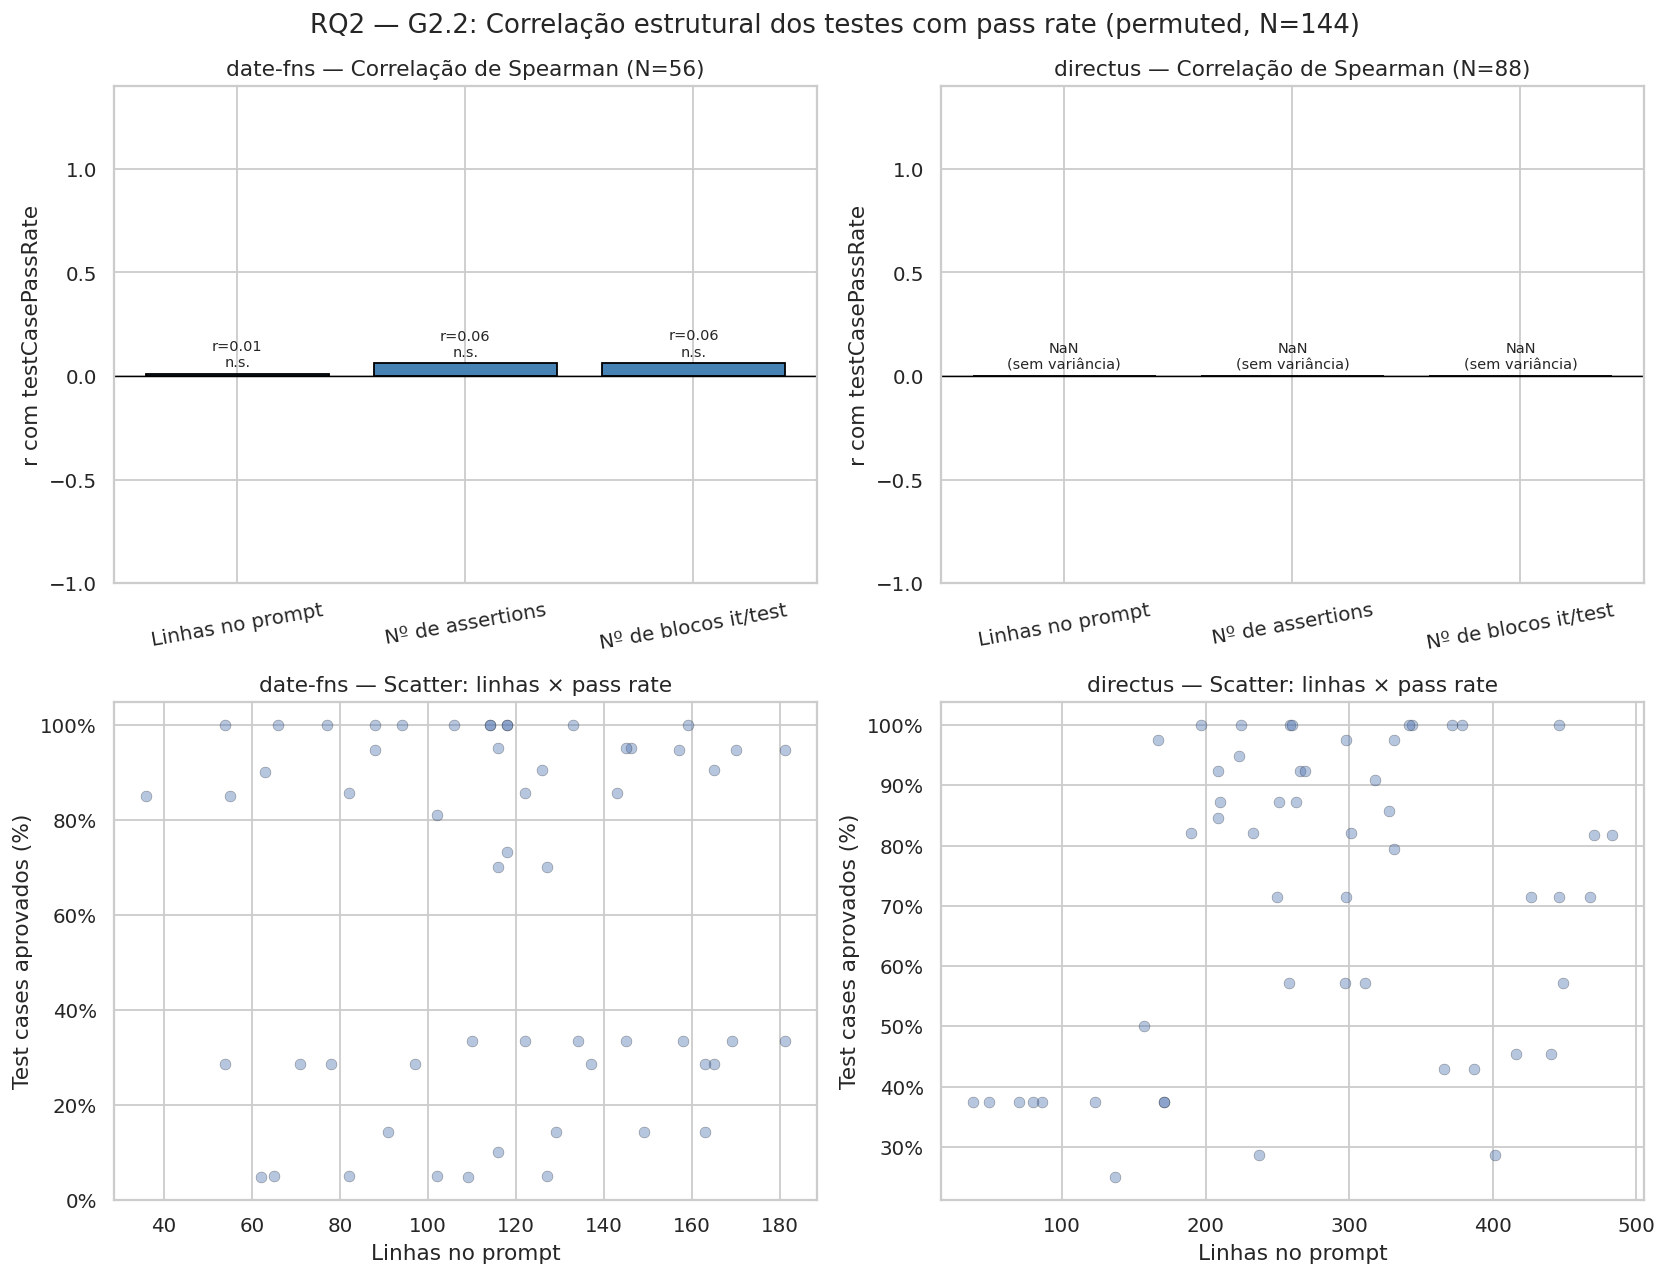

In [41]:
import re, json
from scipy import stats

def extract_test_metrics(prompt_json):
    try:
        prompt = json.loads(prompt_json)
    except Exception:
        prompt = prompt_json
    text = prompt if isinstance(prompt, str) else str(prompt)
    return {
        "num_lines":      text.count("\n"),
        "num_assertions": len(re.findall(r"\bexpect\(|\bassert\b|\bshould\b", text)),
        "num_it_blocks":  len(re.findall(r"\bit\(|test\(", text)),
    }

# Usa permuted para maximizar variância (N=144 vs N=20 no all-relevant)
metrics_df = df[df["contextType"] == "permuted-relevant-test-case"].copy()
extracted  = metrics_df["modelUserPrompt"].apply(extract_test_metrics)
metrics_df = metrics_df.join(pd.DataFrame(extracted.tolist()))

feature_cols = ["num_lines", "num_assertions", "num_it_blocks"]
feat_labels  = ["Linhas no prompt", "Nº de assertions", "Nº de blocos it/test"]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col_idx, repo in enumerate(metrics_df["repositoryName"].unique()):
    d = metrics_df[metrics_df["repositoryName"] == repo]

    # Linha 1: barras de correlação de Spearman
    ax_bar = axes[0][col_idx]
    raw_rs = [stats.spearmanr(d[c], d["testCasePassRate"])[0] for c in feature_cols]
    raw_ps = [stats.spearmanr(d[c], d["testCasePassRate"])[1] for c in feature_cols]
    plot_rs = [r if not np.isnan(r) else 0.0 for r in raw_rs]
    plot_ps = [p if not np.isnan(p) else 1.0 for p in raw_ps]

    bar_colors = ["steelblue" if r >= 0 else "salmon" for r in plot_rs]
    bars = ax_bar.bar(feat_labels, plot_rs, color=bar_colors, edgecolor="black")

    for bar, r_raw, r_plot, p in zip(bars, raw_rs, plot_rs, plot_ps):
        sig   = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        label = "NaN\n(sem variância)" if np.isnan(r_raw) else f"r={r_plot:.2f}\n{sig}"
        y_pos = bar.get_height() + 0.02 if r_plot >= 0 else bar.get_height() - 0.15
        ax_bar.annotate(label, xy=(bar.get_x() + bar.get_width() / 2, y_pos),
                        ha="center", va="bottom", fontsize=8)

    ax_bar.axhline(0, color="black", linewidth=0.8)
    ax_bar.set_ylim(-1, 1.4)
    ax_bar.set_title(f"{repo} — Correlação de Spearman (N={len(d)})")
    ax_bar.set_ylabel("r com testCasePassRate")
    ax_bar.tick_params(axis="x", rotation=10)

    # Linha 2: scatter linhas × pass rate para evidenciar distribuição dos dados
    ax_sc = axes[1][col_idx]
    ax_sc.scatter(d["num_lines"], d["testCasePassRate"] * 100,
                  alpha=0.4, edgecolors="black", linewidths=0.3)
    ax_sc.set_xlabel("Linhas no prompt")
    ax_sc.set_ylabel("Test cases aprovados (%)")
    ax_sc.set_title(f"{repo} — Scatter: linhas × pass rate")
    ax_sc.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle("RQ2 — G2.2: Correlação estrutural dos testes com pass rate (permuted, N=144)")
plt.tight_layout()
plt.savefig("figures/rq2_structural_analysis.png", bbox_inches="tight")
plt.show()

### Gráfico 2.3 — Contribuição de cada teste individual (subconjunto de tamanho 1)

Filtra permutações com apenas 1 teste e mostra qual deles, isoladamente, leva ao maior pass rate por método.

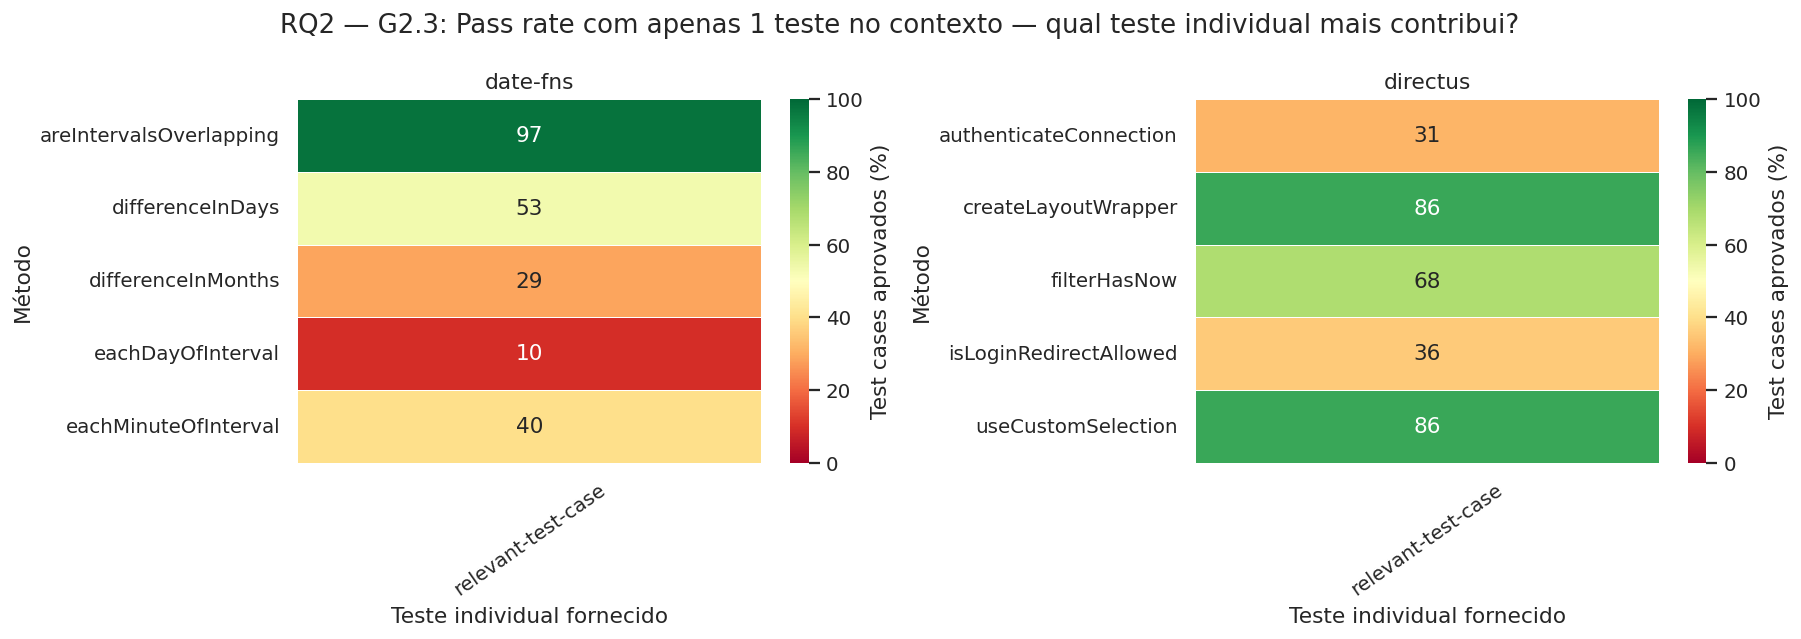

In [42]:
single = df[
    (df["contextType"] == "permuted-relevant-test-case") &
    (df["experimentContextItemCount"] == 1)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, repo in zip(axes, single["repositoryName"].unique()):
    d = single[single["repositoryName"] == repo]
    pivot = (
        d.groupby(["methodName", "experimentContextSlugs"])["testCasePassRate"]
        .mean()
        .unstack("experimentContextSlugs")
        .fillna(0)
    )
    sns.heatmap(pivot * 100, ax=ax, cmap="RdYlGn", vmin=0, vmax=100,
                annot=True, fmt=".0f", linewidths=0.3,
                cbar_kws={"label": "Test cases aprovados (%)"})
    ax.set_title(f"{repo}")
    ax.set_xlabel("Teste individual fornecido")
    ax.set_ylabel("Método")
    ax.tick_params(axis="x", rotation=35)

plt.suptitle("RQ2 — G2.3: Pass rate com apenas 1 teste no contexto — qual teste individual mais contribui?")
plt.tight_layout()
plt.savefig("figures/rq2_single_test_contribution.png", bbox_inches="tight")
plt.show()

## RQ3 — Quais LLMs geram métodos de forma mais eficiente?

### Gráfico 3.1 — Sucesso por modelo e tipo de contexto

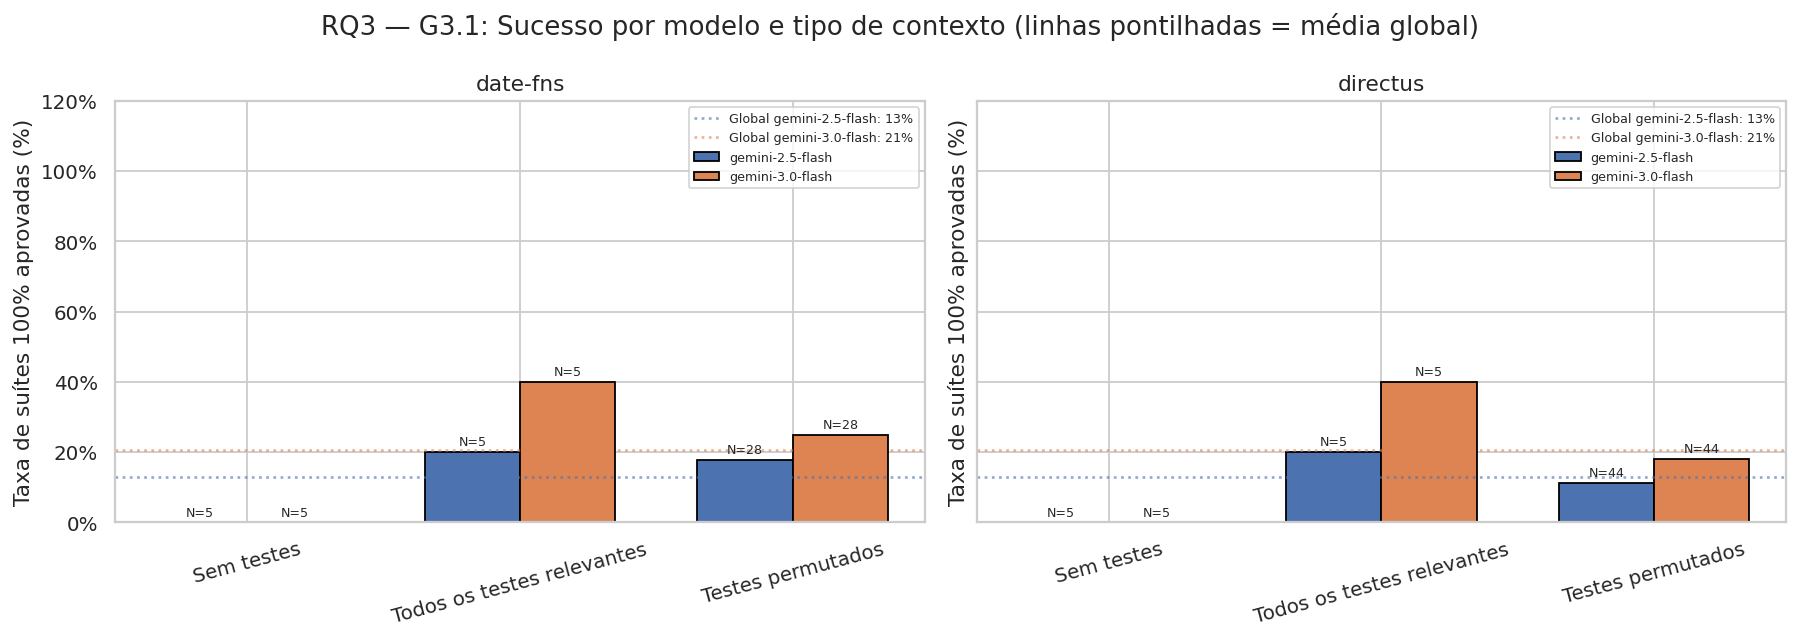

In [43]:
rates = (
    df.groupby(["repositoryName", "modelName", "contextType"])["isTestSuiteSuccessful"]
    .agg(["mean", "count"])
    .reset_index()
)
global_rates = df.groupby("modelName")["isTestSuiteSuccessful"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, repo in zip(axes, df["repositoryName"].unique()):
    d = rates[rates["repositoryName"] == repo]
    ordered  = [c for c in CONTEXT_ORDER if c in d["contextType"].values]
    models   = d["modelName"].unique()
    x        = np.arange(len(ordered))
    width    = 0.35

    for i, model in enumerate(models):
        dm   = d[d["modelName"] == model].set_index("contextType").reindex(ordered, fill_value=0)
        bars = ax.bar(x + i * width, dm["mean"] * 100, width, label=model, edgecolor="black")
        for bar, (idx, row) in zip(bars, dm.iterrows()):
            ax.annotate(f"N={int(row['count'])}",
                        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1),
                        ha="center", va="bottom", fontsize=7)

    # Linhas de taxa global por modelo
    for j, model in enumerate(models):
        ax.axhline(global_rates.get(model, 0) * 100, linestyle=":", color=f"C{j}", alpha=0.6,
                   label=f"Global {model}: {global_rates.get(model, 0)*100:.0f}%")

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([CONTEXT_LABELS.get(c, c) for c in ordered], rotation=15)
    ax.set_title(f"{repo}")
    ax.set_ylabel("Taxa de suítes 100% aprovadas (%)")
    ax.set_ylim(0, 120)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=7)

plt.suptitle("RQ3 — G3.1: Sucesso por modelo e tipo de contexto (linhas pontilhadas = média global)")
plt.tight_layout()
plt.savefig("figures/rq3_model_vs_context.png", bbox_inches="tight")
plt.show()

### Gráfico 3.2 — Compilabilidade por modelo

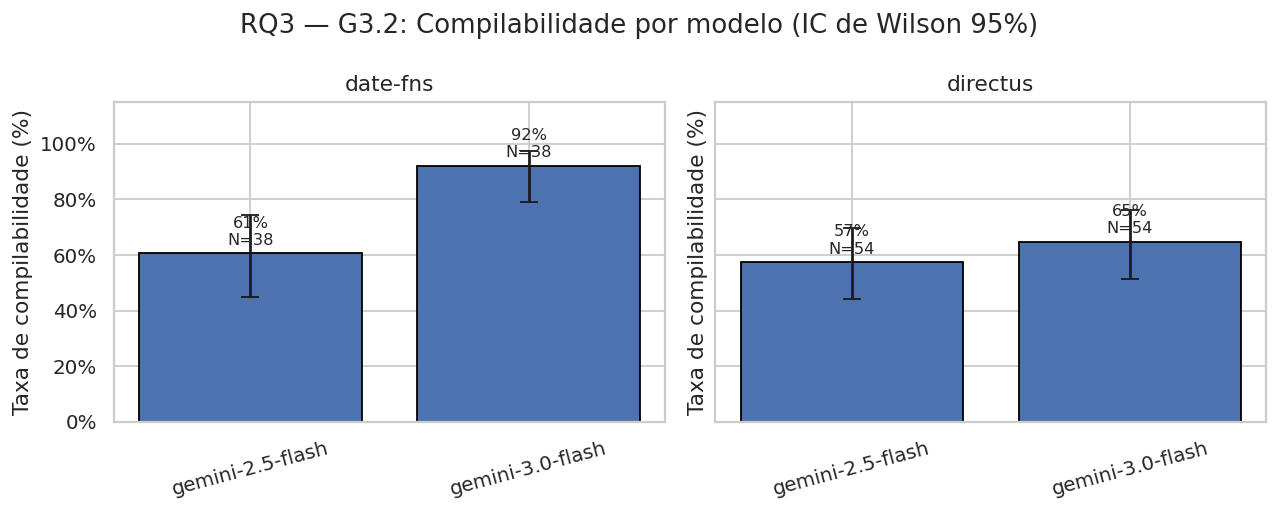

In [44]:
from scipy.stats import norm as _norm

def wilson_ci(successes, n, confidence=0.95):
    z = _norm.ppf((1 + confidence) / 2)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return center - margin, center + margin

comp = (
    df.groupby(["repositoryName", "modelName"])["isModelResultCompilable"]
    .agg(["sum", "count"])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, repo in zip(axes, comp["repositoryName"].unique()):
    d = comp[comp["repositoryName"] == repo]
    means     = d["sum"] / d["count"]
    ci_bounds = [wilson_ci(s, n) for s, n in zip(d["sum"], d["count"])]
    yerr_low  = means - np.array([b[0] for b in ci_bounds])
    yerr_high = np.array([b[1] for b in ci_bounds]) - means

    bars = ax.bar(d["modelName"], means * 100, edgecolor="black",
                  yerr=[yerr_low * 100, yerr_high * 100], capsize=5)
    for bar, val, n in zip(bars, means, d["count"]):
        ax.annotate(f"{val*100:.0f}%\nN={int(n)}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2),
                    ha="center", va="bottom", fontsize=9)

    ax.set_title(f"{repo}")
    ax.set_ylabel("Taxa de compilabilidade (%)")
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("RQ3 — G3.2: Compilabilidade por modelo (IC de Wilson 95%)")
plt.tight_layout()
plt.savefig("figures/rq3_compilability_by_model.png", bbox_inches="tight")
plt.show()

### Gráfico 3.3 — Curva de aprendizado por modelo (Q2 desagregado por modelo)

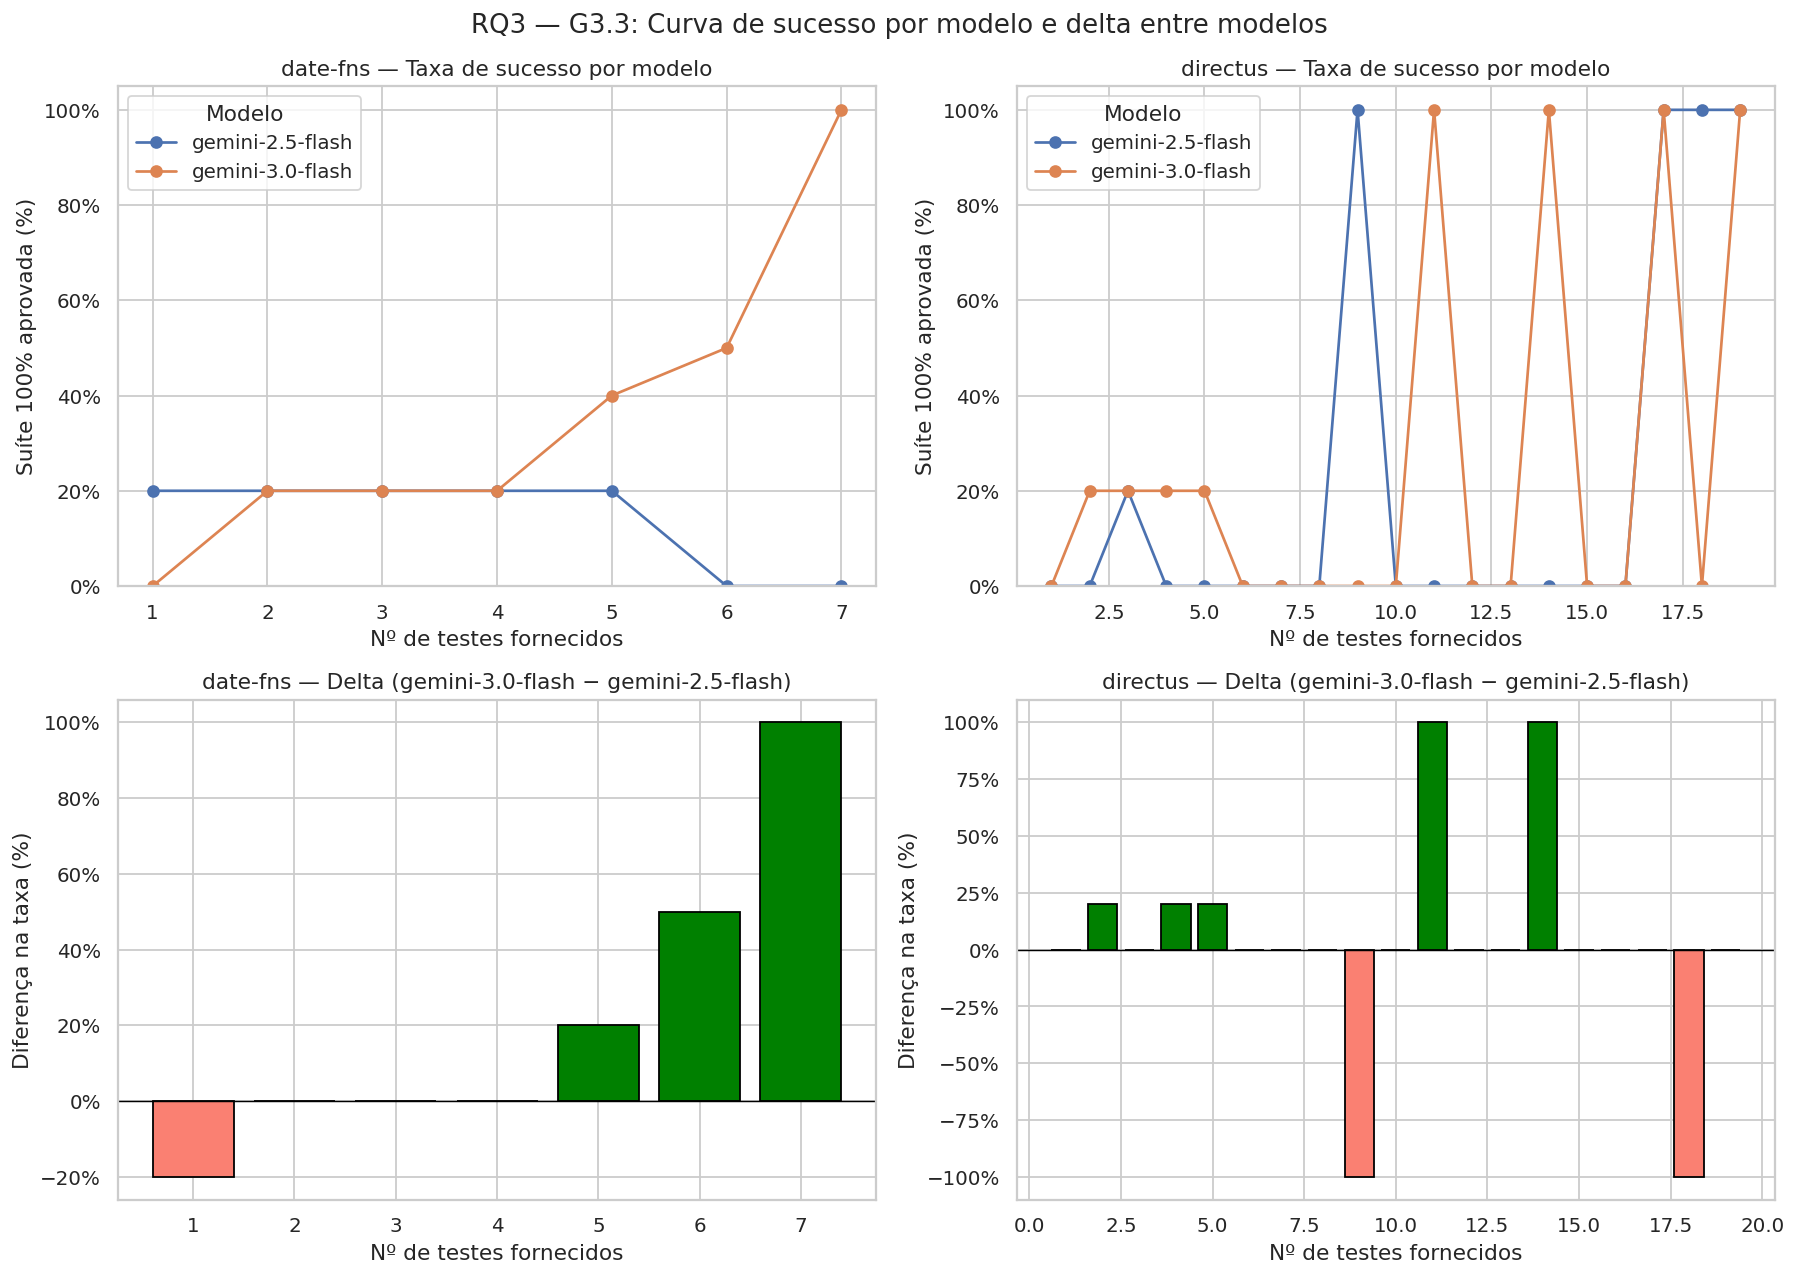

In [45]:
permuted = df[df["contextType"] == "permuted-relevant-test-case"]

impact = (
    permuted.groupby(["repositoryName", "modelName", "experimentContextItemCount"])["isTestSuiteSuccessful"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, repo in enumerate(impact["repositoryName"].unique()):
    d      = impact[impact["repositoryName"] == repo]
    models = d["modelName"].unique()

    # Painel linha: curvas por modelo
    ax_c = axes[0][col_idx]
    for model, group in d.groupby("modelName"):
        group = group.sort_values("experimentContextItemCount")
        ax_c.plot(group["experimentContextItemCount"], group["isTestSuiteSuccessful"] * 100,
                  marker="o", label=model)
    ax_c.set_title(f"{repo} — Taxa de sucesso por modelo")
    ax_c.set_xlabel("Nº de testes fornecidos")
    ax_c.set_ylabel("Suíte 100% aprovada (%)")
    ax_c.set_ylim(0, 105)
    ax_c.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_c.legend(title="Modelo")

    # Painel delta entre modelos
    ax_d = axes[1][col_idx]
    if len(models) == 2:
        pivot = d.pivot(index="experimentContextItemCount", columns="modelName",
                        values="isTestSuiteSuccessful").sort_index()
        m0, m1 = pivot.columns[0], pivot.columns[1]
        delta  = (pivot[m1] - pivot[m0]) * 100
        colors = ["green" if v >= 0 else "salmon" for v in delta]
        ax_d.bar(delta.index, delta, color=colors, edgecolor="black")
        ax_d.axhline(0, color="black", linewidth=0.8)
        ax_d.set_title(f"{repo} — Delta ({m1} − {m0})")
        ax_d.set_xlabel("Nº de testes fornecidos")
        ax_d.set_ylabel("Diferença na taxa (%)")
        ax_d.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle("RQ3 — G3.3: Curva de sucesso por modelo e delta entre modelos")
plt.tight_layout()
plt.savefig("figures/rq3_model_test_count_curve.png", bbox_inches="tight")
plt.show()

### Gráfico 3.4 — Comparação pareada por método (win/tie/loss)

Evita que o agregado esconda qual modelo domina em métodos específicos vs. casos difíceis.

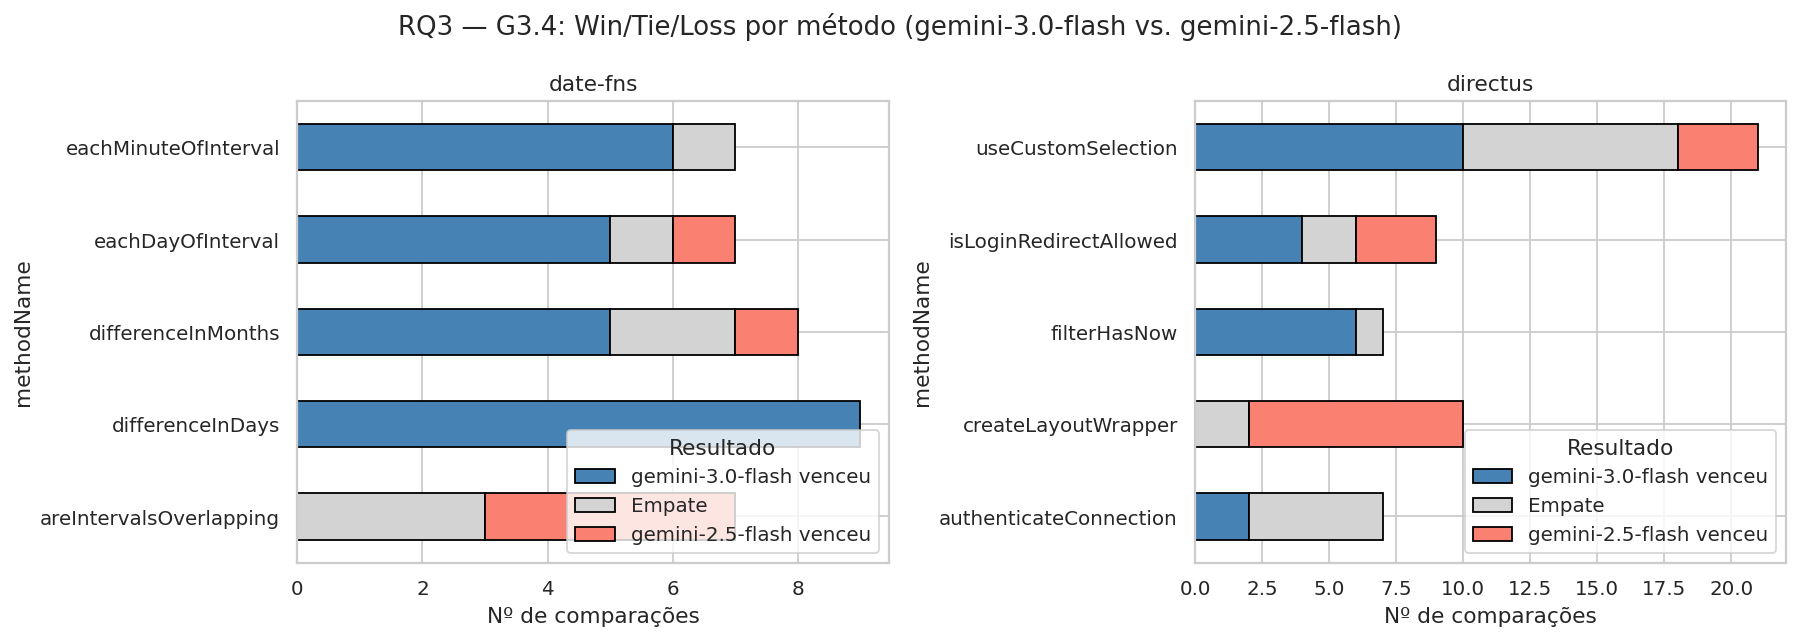

In [46]:
models = df["modelName"].unique()
if len(models) != 2:
    print("Essa análise requer exatamente 2 modelos no dataset.")
else:
    m0, m1 = models[0], models[1]

    left  = df[df["modelName"] == m0][["repositoryName", "methodName", "contextType",
                                        "experimentContextItemCount", "testCasePassRate"]]
    right = df[df["modelName"] == m1][["repositoryName", "methodName", "contextType",
                                        "experimentContextItemCount", "testCasePassRate"]]
    paired = left.merge(right,
                        on=["repositoryName", "methodName", "contextType", "experimentContextItemCount"],
                        suffixes=(f"_{m0}", f"_{m1}"))

    def outcome(row):
        a, b = row[f"testCasePassRate_{m0}"], row[f"testCasePassRate_{m1}"]
        if abs(a - b) < 0.01: return "Empate"
        return f"{m1} venceu" if b > a else f"{m0} venceu"

    paired["outcome"] = paired.apply(outcome, axis=1)

    summary = (
        paired.groupby(["repositoryName", "methodName", "outcome"])
        .size()
        .unstack("outcome", fill_value=0)
        .reset_index()
    )

    outcome_order  = [f"{m1} venceu", "Empate", f"{m0} venceu"]
    outcome_colors = {"Empate": "lightgray"}
    outcome_colors[f"{m1} venceu"] = "steelblue"
    outcome_colors[f"{m0} venceu"] = "salmon"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, repo in zip(axes, summary["repositoryName"].unique()):
        d     = summary[summary["repositoryName"] == repo].set_index("methodName")
        cols  = [c for c in outcome_order if c in d.columns]
        colors = [outcome_colors[c] for c in cols]
        d[cols].plot(kind="barh", stacked=True, ax=ax, color=colors, edgecolor="black")
        ax.set_title(f"{repo}")
        ax.set_xlabel("Nº de comparações")
        ax.legend(title="Resultado")

    plt.suptitle(f"RQ3 — G3.4: Win/Tie/Loss por método ({m1} vs. {m0})")
    plt.tight_layout()
    plt.savefig("figures/rq3_win_loss_by_method.png", bbox_inches="tight")
    plt.show()